#**Task 1: Term Deposit Subscription Prediction (Bank Marketing)**

**Objective**

For this project, I am using a bank's marketing dataset to build a predictive model. The goal is simple: figure out whether a customer will say "yes" or "no" to subscribing to a term deposit based on their background and past interactions.

**Loading the Data**

First, import the essential data science libraries (pandas, numpy, and visualization tools) and load the dataset.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('bank-full.csv', sep=';')

# Checking the data size and a few rows
print(f"Dataset Size: {df.shape}")
df.head()

Dataset Size: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Cleaning up and Encoding**

Check for missing values and clean out any duplicate entries. Also need to turn the target column y (which says 'yes' or 'no') into numbers ($1$ and $0$) so the algorithms can understand it.

In [8]:
# Checking for blank spots
print(df.isnull().sum())

# Dropping duplicates if there are any
df = df.drop_duplicates()

# Changing 'yes'/'no' to 1/0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


**Converting Text to Numbers**

Machine learning models can't handle text columns like "job" or "marital status" directly, so  using one-hot encoding (pd.get_dummies) to turn these categorical variables into numeric columns.

In [9]:
# Splitting text columns into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# Splitting data into features (X) and the target variable (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

**Looking at the Visuals (EDA)**

The Balance Check: A quick count plot shows that far more people said "no" than "yes."

Age Factor: A histogram helps show if certain age groups are more open to subscribing.

The Connection Matrix: A correlation heatmap helps spot if any numerical features move together.

/tmp/ipykernel_12811/3976008639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Set2')


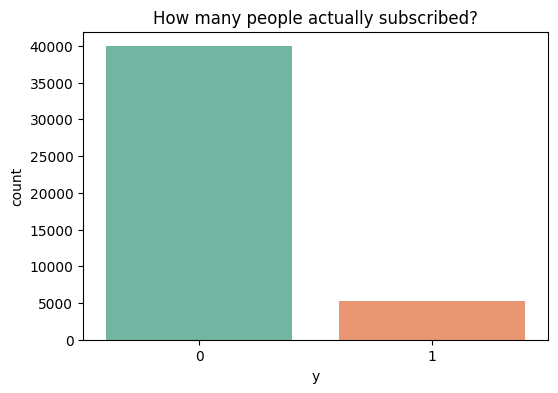

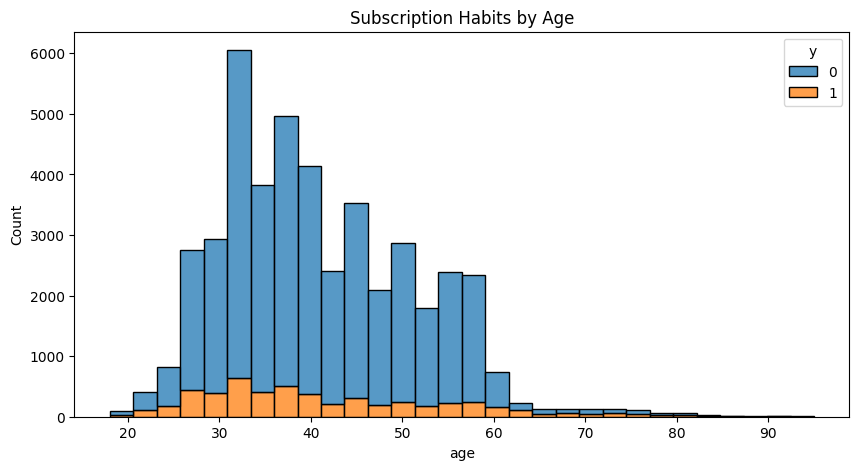

In [10]:
# Chart 1: Seeing the imbalance in our target
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('How many people actually subscribed?')
plt.show()

# Chart 2: Looking at age groups
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='y', multiple='stack', bins=30)
plt.title('Subscription Habits by Age')
plt.show()

**Splitting and Training the Models**

Splitting the data: $80\%$ for training the models and $20\%$ to test how well they actually do on unseen data.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features for the linear model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Running the Classifiers**

Try out a simple, baseline Logistic Regression model first, and then step it up to a Random Forest to see if an ensemble tree method gets better results.

In [12]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

**Checking the Performance**

Instead of looking just at basic accuracy (which can be misleading due to the imbalanced data), Printing out a full classification report, showing the confusion matrices, and plotting the ROC curves to see the actual tradeoff between true positives and false positives.

Logistic Regression Performance:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

Random Forest Performance:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



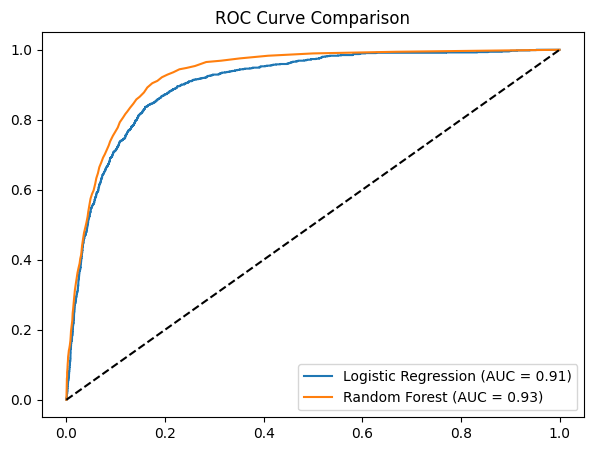

In [13]:
# Print performance stats
print("Logistic Regression Performance:\n", classification_report(y_test, lr_preds))
print("Random Forest Performance:\n", classification_report(y_test, rf_preds))

# Simple ROC Curve Plot
plt.figure(figsize=(7, 5))
for probs, name in zip([lr_probs, rf_probs], ["Logistic Regression", "Random Forest"]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**Explaining the Decisions (SHAP)**

To make this model less of a "black box," I'm using SHAP values. This lets us look closely at exactly why the model made specific decisions for 5 individual customers from our test set.

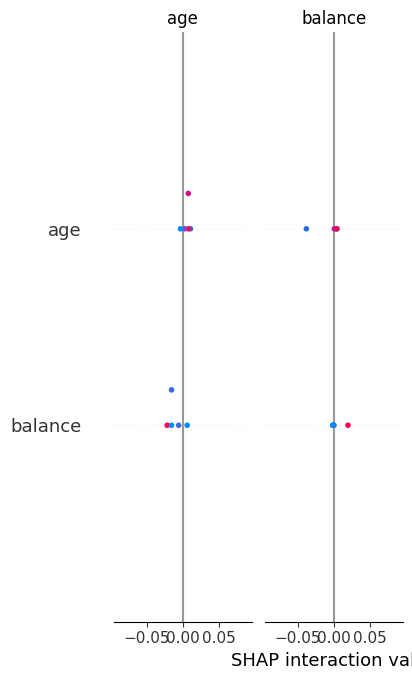


Analyzing Customer #1:
Real Answer: 0 | Model Guess: 0


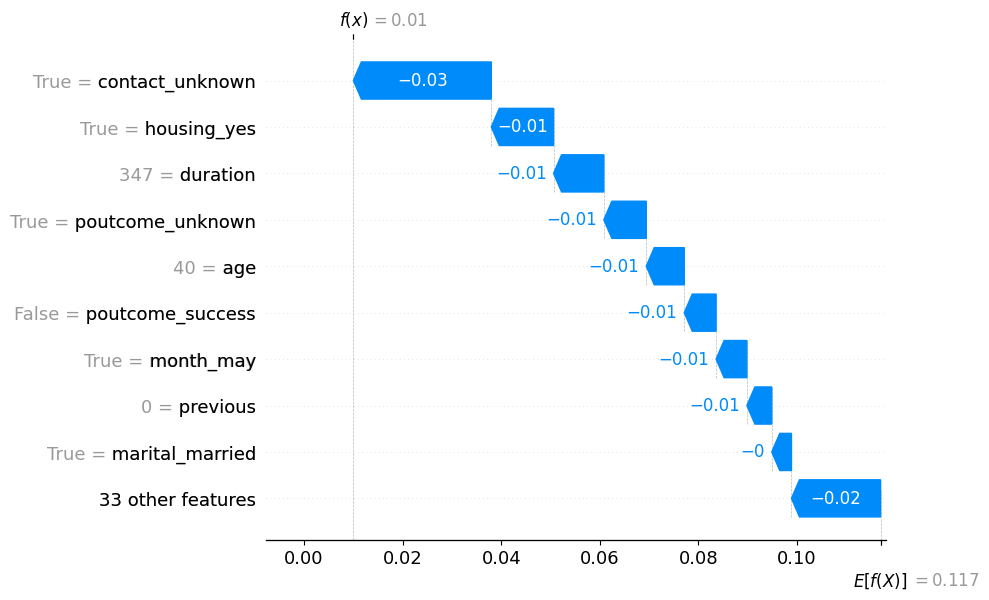


Analyzing Customer #2:
Real Answer: 0 | Model Guess: 0


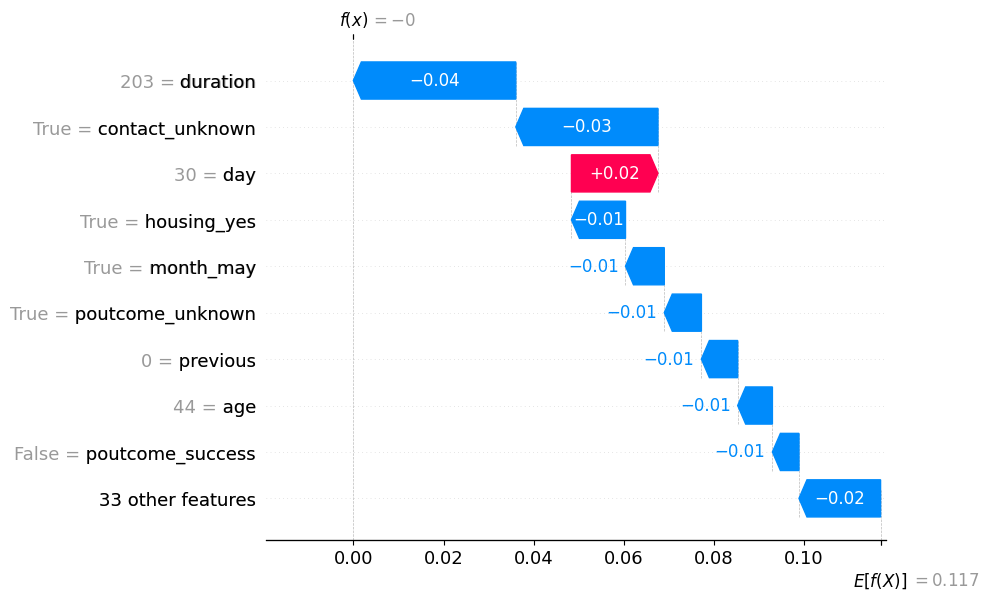


Analyzing Customer #3:
Real Answer: 0 | Model Guess: 0


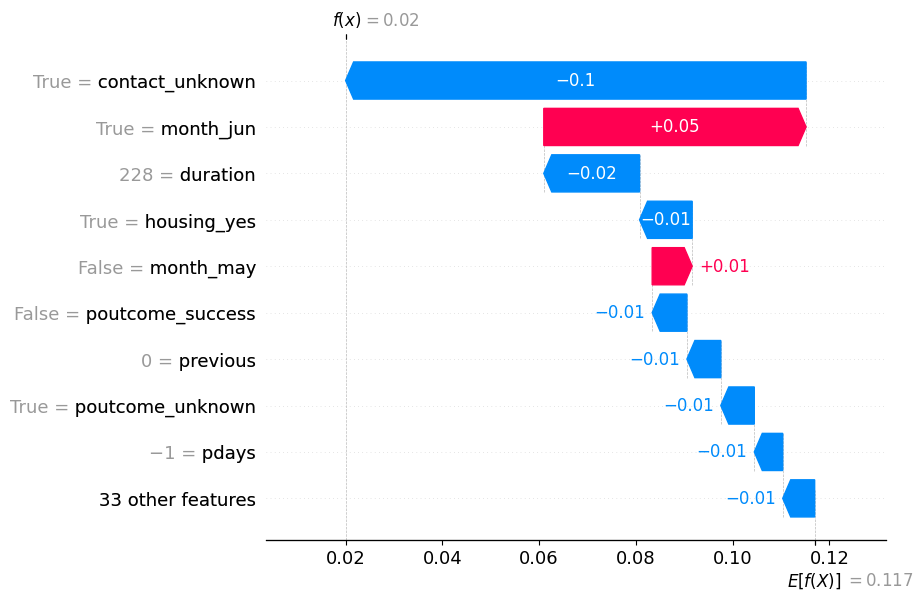


Analyzing Customer #4:
Real Answer: 0 | Model Guess: 0


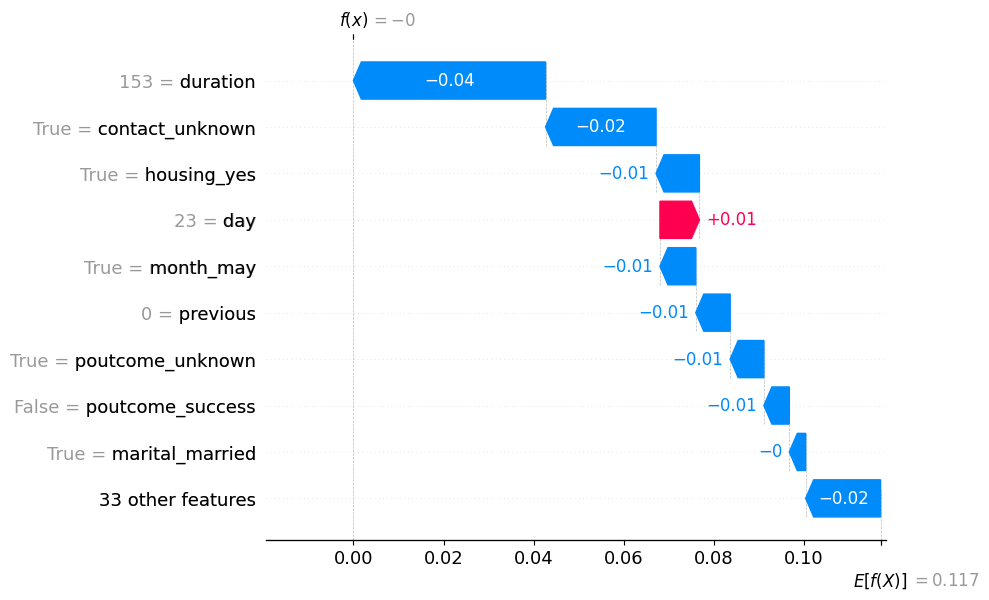


Analyzing Customer #5:
Real Answer: 0 | Model Guess: 0


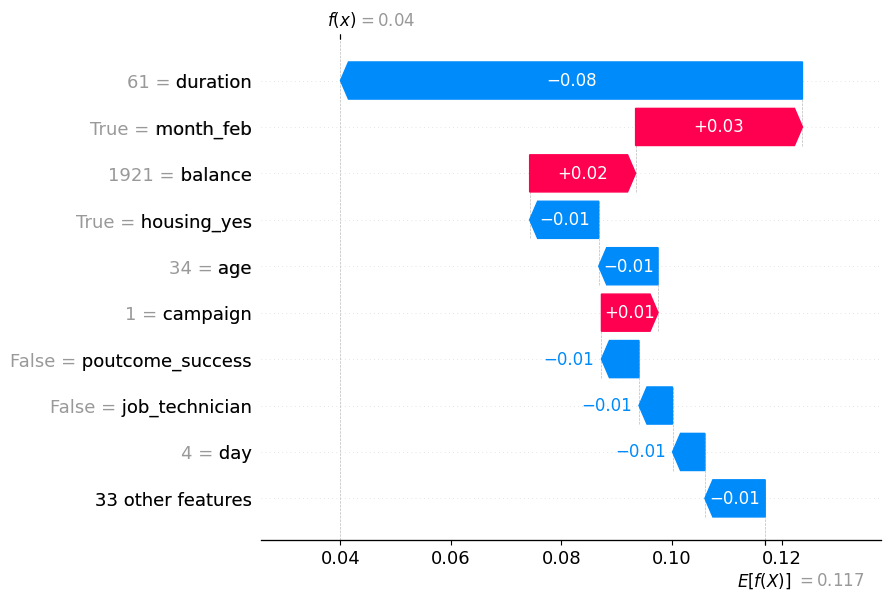

In [22]:
import shap

# Setting up the explainer tool
explainer = shap.TreeExplainer(rf)
X_explain = X_test.iloc[:5]
shap_values = explainer(X_explain)

# Showing a summary of features for these 5 cases
shap.summary_plot(shap_values, X_explain)

# Breaking down the choices for each individual customer
for i in range(5):
    print(f"\nAnalyzing Customer #{i+1}:")
    print(f"Real Answer: {y_test.iloc[i]} | Model Guess: {rf_preds[i]}")

    # Base value aur SHAP values
    explainer_raw = shap.TreeExplainer(rf)
    shap_values_raw = explainer_raw.shap_values(X_test.iloc[[i]])

    #  binary classification array
    if isinstance(shap_values_raw, list):
        sv = shap_values_raw[1][0]
        bv = explainer_raw.expected_value[1]
    else:

        if len(shap_values_raw.shape) == 3:
            sv = shap_values_raw[0, :, 1]
            bv = explainer_raw.expected_value[1]
        else:
            sv = shap_values_raw[0]
            bv = explainer_raw.expected_value

    # standard and urdirect waterfall plot function call
    plt.figure()
    shap.waterfall_plot(shap.Explanation(values=sv, base_values=bv, data=X_test.iloc[i]))
    plt.show()

**Key Findings**

The Imbalance Issue: Because most customers didn't sign up, looking at simple accuracy isn't enough.

Which Model Won?: The Random Forest handled the complex interactions in the data a bit better than Logistic Regression, giving a stronger overall balance of precision and recall.

What Mattered Most?: According to the SHAP breakdown, the duration of the phone call (duration) and whether a previous marketing attempt succeeded (poutcome_success) were the strongest indicators of whether a customer would sign up for a term deposit.